In [41]:
from typing import Literal, TypedDict

from dotenv import load_dotenv
from langchain_mistralai import ChatMistralAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()

True

In [42]:
model= ChatMistralAI(model='mistral-medium-latest')

In [43]:
class Segment(BaseModel):
    name: str = Field(description="The name/identifier of this segment (e.g., 'welcome', 'intro', 'discussion', 'outro')")
    description: str = Field(description="Detailed guidelines for writing this segment, including tone, content requirements, and approximate length")

class PodcastDetails(BaseModel):
    topic: str = Field(description="The main topic of the podcast episode")
    host_persona: dict = Field(
        description=(
            "Details about the host in JSON format that would help build a unique persona with at least 4 traits (e.g. vocabulary level, humor style, catchphrases, energy level)"
        )
    )
    guest_persona: dict = Field(
        description=(
            "Details about the guest in JSON format that would help build a unique persona with at least 4 traits (e.g. expertise, speaking style, personality quirks, communication approach)"
        )
    )
    podcast_name: str = Field(
        description=(
            "Name or Title of the podcast"
        )
    )
    platform_name: str = Field(
        description=(
            "Name or Title of the platform hosting the podcast"
        )
    )
    segments: list[Segment] = Field(
        description=(
            "A list of segments that make up the podcast structure, in order. Each segment should have a name and description. The following segments should be minimally included: welcome (host opens the show), intro (guest introduction), discussion (main topic exploration), outro (wrap-up and sign-off). You can add, remove, or rename segments based on what makes sense for this specific podcast. Try to include a mix of natural and scripted segments with more than the minimally required segments."
        )
    )

In [44]:
detail_model= model.with_structured_output(PodcastDetails)

In [45]:
class ScriptGen(TypedDict):
    user_input: str

    podcast_name: str
    platform_name: str
    topic: str
    host_persona: dict
    guest_persona: dict

    # The segment structure (name, description) for the podcast
    segment_structure: list[dict]
    # Index of the current segment being generated
    current_segment_index: int

    # Generated script segments
    segments: list[dict]

    is_complete: bool
    human_feedback: str

In [46]:
# Helper function to get segment guidelines from the structure
def get_segment_guideline(segment_name: str, segment_structure: list[dict]) -> str:
    """Get the description/guidelines for a specific segment."""
    for seg in segment_structure:
        if seg["name"] == segment_name:
            return seg["description"]
    return "Write a natural podcast segment."

In [ ]:
def parse_input_node(state: ScriptGen) -> ScriptGen:
    """Parse user input and extract topic + personas + segment structure as JSON."""
    user_input = state["user_input"]

    details = detail_model.invoke(user_input)

    # Convert Segment objects to dicts for state storage
    segment_structure = [
        {"name": seg.name, "description": seg.description}
        for seg in details.segments
    ]

    return {
        "topic": details.topic,
        "host_persona": details.host_persona,
        "guest_persona": details.guest_persona,
        "podcast_name": details.podcast_name,
        "platform_name": details.platform_name,
        "segment_structure": segment_structure,
        "current_segment_index": 0,
        "segments": [],
        "is_complete": False
    }

def generate_segment_node(state: ScriptGen) -> ScriptGen:
    """Generate the next segment, or regenerate the last one if feedback exists."""

    segment_structure = state["segment_structure"]
    current_index = state["current_segment_index"]
    topic = state["topic"]
    podcast_name = state["podcast_name"]
    platform_name = state["platform_name"]
    host = state["host_persona"]
    guest = state["guest_persona"]
    segments = list(state.get("segments", []))
    feedback = state.get("human_feedback", "").strip()

    # Get current segment info
    current_segment = segment_structure[current_index]
    segment_name = current_segment["name"]
    segment_guideline = current_segment["description"]

    # ── Case 1: Re-generate the last segment with human feedback ──
    if feedback and segments:
        last = segments[-1]
        prompt = f"""You are a podcast script writer. Rewrite the following
                    "{last['type']}" segment based on the reviewer's feedback.

                    --- ORIGINAL SEGMENT ---
                    {last['content']}

                    --- REVIEWER FEEDBACK ---
                    {feedback}

                    --- CONTEXT ---
                    Podcast Name  : {podcast_name}
                    Platform Name : {platform_name}
                    Topic         : {topic}
                    Host          : {host}
                    Guest         : {guest}

                    Rules:
                    • Keep the HOST: / GUEST: label format.
                    • Ensure the host and guest voices remain clearly distinct.
                    • Apply the feedback precisely; do not change anything the reviewer didn't mention.
                    • Output ONLY the rewritten script dialogue.
                    • Do NOT include any preamble, introduction, summary of changes, or commentary.
                    • Your response MUST start with HOST: or GUEST: and end with the final line of dialogue.
                    """
        response = model.invoke(prompt)
        segments[-1] = {
            "type": last["type"],
            "content": response.content,
        }
        return {"segments": segments, "human_feedback": ""}

    # ── Case 2: Generate a brand-new segment ──
    previous_context = ""
    if segments:
        prev_text = "\n\n".join(
            f"{s['content']}" for s in segments
        )
        previous_context = (
            f"Here are the segments generated so far (for continuity):\n"
            f"{prev_text}\n\n"
        )

    prompt = f"""You are a podcast script writer.  Write the
                "{segment_name}" segment for a podcast episode.

                Podcast Name  : {podcast_name}
                Platform Name : {platform_name}
                Topic         : {topic}
                Host persona  : {host}
                Guest persona : {guest}

                Segment guidelines: {segment_guideline}

                {previous_context}

                Rules:
                • Format every line as  HOST: <dialogue>  or  GUEST: <dialogue>.
                • The host's language, vocabulary, and energy MUST reflect their persona.
                • The guest's language, vocabulary, and energy MUST reflect their persona.
                • The dialogue must sound natural — include filler words, reactions,
                interruptions where appropriate.
                • Do NOT include stage directions or parentheticals.
                • Output ONLY the script dialogue.
            """
    response = model.invoke(prompt)
    segments.append({
        "type": segment_name,
        "content": response.content,
    })
    return {"segments": segments, "human_feedback": ""}


def human_interrupt_node(state: ScriptGen) -> ScriptGen:
    """Passthrough node. The graph pauses BEFORE this node so the human
    can inspect the latest segment and optionally set `human_feedback`
    via `update_state`.  When the graph resumes this node simply
    passes the (possibly updated) state forward."""
    return {}


def check_completion_node(state: ScriptGen) -> ScriptGen:
    """Advance `current_segment_index` to the next in order, or flag completion."""

    current_index = state["current_segment_index"]
    segment_structure = state["segment_structure"]

    if current_index >= len(segment_structure) - 1:
        return {"is_complete": True}

    return {
        "current_segment_index": current_index + 1,
        "is_complete": False,
    }



def after_human_review(state: ScriptGen) -> Literal["generate_segment", "check_completion"]:
    """If the reviewer left feedback → regenerate.  Otherwise → move on."""

    if state.get("human_feedback", "").strip():
        return "generate_segment"
    return "check_completion"


def should_continue(state: ScriptGen) -> Literal["generate_segment", "end"]:
    """After check_completion: generate next segment or finish."""

    if state.get("is_complete", False):
        return "end"
    return "generate_segment"

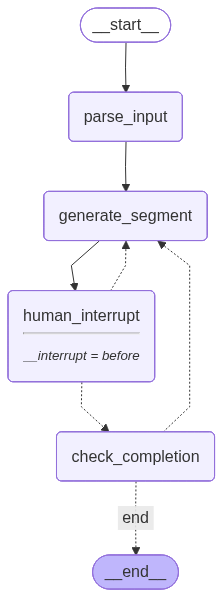

In [48]:
graph = StateGraph(ScriptGen)

graph.add_node("parse_input", parse_input_node)
graph.add_node("generate_segment", generate_segment_node)
graph.add_node("human_interrupt", human_interrupt_node)
graph.add_node("check_completion", check_completion_node)

graph.add_edge(START, "parse_input")
graph.add_edge("parse_input", "generate_segment")
graph.add_edge("generate_segment", "human_interrupt")

graph.add_conditional_edges(
    "human_interrupt",
    after_human_review,
    {
        "generate_segment": "generate_segment",
        "check_completion": "check_completion",
    },
)

graph.add_conditional_edges(
    "check_completion",
    should_continue,
    {
        "generate_segment": "generate_segment",
        "end": END,
    },
)

memory = InMemorySaver()  

compiled_graph = graph.compile(
    interrupt_before=["human_interrupt"],
    checkpointer=memory,
)

compiled_graph

In [49]:
initial_state = {
    'user_input': 'Podcast called Test on the platform spoootify about wildlife with a uneducated host and a guest with PhD in wildlife health'
}
config= {'configurable':{'thread_id': '1'}}

final_state = compiled_graph.invoke(initial_state, config)
final_state

{'user_input': 'Podcast called Test on the platform spoootify about wildlife with a uneducated host and a guest with PhD in wildlife health',
 'podcast_name': 'Test',
 'platform_name': 'Spoootify',
 'topic': 'Wildlife Health and Conservation',
 'host_persona': {'vocabulary_level': 'basic and colloquial, often using slang or incorrect terminology',
  'humor_style': 'self-deprecating and goofy, often laughing at their own mistakes',
  'catchphrases': ['Well, would ya look at that!',
   'I ain’t no expert, but...',
   'Hold on, let me wrap my brain around that.'],
  'energy_level': 'high and enthusiastic, but prone to tangents',
  'curiosity': 'genuine but uninformed, often asking naive questions',
  'empathy': 'strong, especially for animals and conservation efforts'},
 'guest_persona': {'expertise': 'wildlife health, disease ecology, and conservation biology',
  'speaking_style': 'clear, articulate, and patient, but occasionally uses technical jargon',
  'personality_quirks': 'calm and 

In [50]:
snapshot = compiled_graph.get_state(config)
print("Next node to execute:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))

current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")

print(snapshot.values["segments"][-1]["content"])

Next node to execute: ('human_interrupt',)
Current segment index: 0
Segments so far: 1
Current segment: welcome
**HOST:** Alrighty, alrighty, alright—welcome back, ya beautiful bunch of animal-lovin’, nature-nuttin’ weirdos to another episode of *Tes—* wait, no—*Test*? *Test* the podcast? That don’t sound right. Hold on, let me wrap my brain around that. Ohhh, it’s *Test* on *Spoootify*—yeah, that’s the one! With three O’s! Or is it four? Eh, we’ll figure it out.

**HOST:** Anyway! Today we’re talkin’ about somethin’ near and dear to my heart—well, near and dear to *my* heart, but also probably near and dear to *your* heart unless you’re some kinda robot who don’t like baby seals, and if that’s the case, why are you even here? Get outta my podcast!

**HOST:** But for real, we’re divin’ into *wildlife health and conservation*—which, full disclosure, I ain’t no expert on. Like, I once tried to save a squirrel that was just *vibin’* on my porch, and it turned out it was just takin’ a nap.

In [51]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node to execute:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))

current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")

print(snapshot.values["segments"][-1]["content"])

Next node to execute: ('human_interrupt',)
Current segment index: 1
Segments so far: 2
Current segment: host_confession
**HOST:** Alright, we’re back! And listen—I gotta come clean about somethin’. Y’all know I *love* animals. Like, *love* ‘em. I cry at those ASPCA commercials with the sad Sarah McLachlan music, I name every bug that crawls into my apartment, I once spent 20 minutes tryin’ to convince a pigeon to be my friend with breadcrumbs—spoiler, it *did not* work, and I think it might’ve been mockin’ me.

**HOST:** But here’s the thing—I ain’t no wildlife expert. Like, *at all.* And I got *proof.* So, Dr. [Guest’s Name], before we dive into the *real* science stuff, I gotta share my most *embarrassing* wildlife moment. ‘Cause if we’re talkin’ conservation, we gotta talk about *my* personal contribution to the cause—which was *negative.*

**HOST:** Okay, so last summer, I’m at this lake, right? And I see this *tiny* little turtle just chillin’ on a rock, soakin’ up the sun. And I’

In [52]:
final_state= compiled_graph.update_state(
    config,
    {"human_feedback": "Make the host sound more professional here."},
    as_node="human_interrupt"
)

# Resume → human_interrupt → routes back to generate_segment (rewrites welcome) → pauses again
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))
current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment index: 1
Segments so far: 2
Current segment: host_confession
**HOST:** Alright, we’re back! And before we dive into today’s topic, I’ve got a confession to make. You all know I’m a huge animal lover—I tear up at those ASPCA commercials, I’ve named every bug that’s wandered into my apartment, and yes, I once spent 20 minutes trying to befriend a pigeon with breadcrumbs. Spoiler: It did not work, and I’m pretty sure it was judging me.

**HOST:** But here’s the thing—I’m *not* a wildlife expert. Not even close. And I’ve got the stories to prove it. So, Dr. [Guest’s Name], before we get into the real science, I’ve got to share my most embarrassing wildlife moment. Because if we’re talking conservation, I should probably admit that my personal contribution has been… less than helpful.

**HOST:** Okay, so last summer, I was at a lake, and I spotted this tiny creature sunning itself on a rock. I thought, *“Look at this little turtle! Living its 

In [53]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))
current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment index: 2
Segments so far: 3
Current segment: intro
**HOST:** Alright, welcome back to *Test*—still not sure if that’s the right name, but we’re rollin’ with it! And we are *so* lucky today ‘cause we got a *real-deal* wildlife whiz on the line! Now, I *tried* to do my homework, I *swore* I did, but then I got distracted by a video of a duck wearing a hat, and suddenly it’s 2 AM and I still don’t know how to pronounce your title. But I’m gonna *try*—here we go—Dr. Eleanora… Eleanora… *Eleanorator*—

**GUEST:** *Laughs* Oh boy. It’s Dr. Elinor Hart. But really, just Elinor is fine.

**HOST:** *Elinor!* Okay, *Elinor*—got it. I was *this* close to callin’ you “Dr. Elephant” and just leanin’ into it. But hey, at least I didn’t say “Dr. Hart *Attack*—”

**GUEST:** *Laughing* Please don’t.

**HOST:** Too late, it’s out there now. Folks, we got Dr. Elinor “The Hart Attack” Hart—*new* podcast title, who’s with me? No? Just me? Cool, cool.

**HOST:

In [54]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))
current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment index: 3
Segments so far: 4
Current segment: wildlife_101
=== WILDLIFE_101 ===

**HOST:** Alright, we’re back! And Elinor, I gotta say, my *mind* is *blown*. Like, I knew animals got sick, but I didn’t realize it was this whole *spy movie* level of disease spreadin’ and habitat protectin’ and raccoons eatin’ *fancy medicine bait*. It’s like *Mission: Impossible*, but with more trash pandas.

**GUEST:** *Laughs* I love that you’ve now dubbed raccoons “trash pandas” twice. But yeah, it *is* kind of like a spy movie—except instead of Tom Cruise running on walls, it’s scientists tracking how a virus moves through a bat colony.

**HOST:** Okay, *bats*? Now you’re speakin’ my language! I *love* bats. They’re like if a mouse and a tiny vampire had a *super* cute baby. But also, they’re *terrifyin’*—like, one wrong move and suddenly you’re in a *Batman* origin story, but you’re *not* the hero.

**GUEST:** *Chuckles* Bats are actually *incredibly*

In [55]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))
current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment index: 4
Segments so far: 5
Current segment: deep_dive
=== DEEP_DIVE ===

**HOST:** Alright, Elinor, we’ve been dancin’ around the *real* deep stuff, and I *need* to know—what’s the *wildest* case you’ve ever worked on? Like, the kind of thing where you’re out in the field, and you’re just like, *“Oh no. Ohhh no. This is *bad*.”* Give me the *juicy* details. Was it, like, a zombie deer apocalypse? ‘Cause I *swear* I saw a meme about that once.

**GUEST:** *Laughs* Oh man, okay, I *do* have a good one. So a few years back, I was working in the Rocky Mountains, and we started getting reports of these *really* strange behaviors in elk. They were stumbling around, drooling, just… not acting right. At first, people thought maybe it was rabies, but the tests came back negative. So we’re all scratching our heads, and then—*bam*—we get a call about a *moose* doing the same thing. And moose are *not* animals you want acting erratic. Those things a

In [56]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))
current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment index: 5
Segments so far: 6
Current segment: audience_question
**HOST:** Alright, we’re back, and it’s time for my *favorite* part of the show—*Audience Questions That Make Me Realize How Little I Know About Anything*! We got a *doozy* today, folks. This one’s from *@NatureNerd88*—shoutout to you, buddy—who asks: *“If a squirrel gets the hiccups, does its whole tiny body just, like, *yeet* itself into a tree? Asking for a friend.”*

**GUEST:** *Laughs* Oh man, that’s… that’s a *great* question. And honestly? I’ve never been asked about squirrel hiccups before.

**HOST:** *Wait, what?* You’re tellin’ me you *don’t* know? But you’re the *expert*! I was *countin’* on you to give me a *scientific breakdown* of squirrel spasms! Now I’m just picturin’ a squirrel goin’ *“HIC*—*oh no*—*HIC*—*I’M GONNA DIE*—” and then *faceplantin’* into a bush.

**GUEST:** *Chuckles* Okay, so—*technically*—squirrels *can* get hiccups, just like most mammals. But 

In [57]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))
current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment index: 6
Segments so far: 7
Current segment: conservation_corner
=== CONSERVATION_CORNER ===

**HOST:** Alrighty, folks, we’re back, and it’s time for *Conservation Corner*—the part of the show where we stop *talkin’* about problems and start *doin’* somethin’ about ‘em! Or, y’know, where *I* stop talkin’ and Elinor tells *me* what to do, ‘cause let’s be real, my last attempt at “helping” involved a turtle that was *actually* a rock. But hey, we *learn*, we *grow*, we *accidentally fall into ponds*—it’s a journey!

**GUEST:** *Laughs* I love that your conservation motto is basically “try, fail, but try again.”

**HOST:** *Exactly!* And today, I *really* wanna try, ‘cause I’ve been sittin’ here learnin’ all this stuff about sick moose and cat poop otters and *hiccupin’* squirrels, and I’m like, *“Man, I wanna *help*! But how?!”* Like, do I need to go to vet school? ‘Cause I *barely* passed high school biology, and that was only ‘cause my t

In [58]:
final_state= compiled_graph.invoke(None, config)

snapshot = compiled_graph.get_state(config)
print("Next node:", snapshot.next)
print("Current segment index:", snapshot.values["current_segment_index"])
print("Segments so far:", len(snapshot.values["segments"]))
current_segment_name = snapshot.values["segment_structure"][snapshot.values["current_segment_index"]]["name"]
print(f"Current segment: {current_segment_name}")
print(snapshot.values["segments"][-1]["content"])

Next node: ('human_interrupt',)
Current segment index: 7
Segments so far: 8
Current segment: outro
**HOST:** Alrighty, alrighty, alright—well, would ya look at that, folks! We made it to the *end* of another episode of *Test*—still not sure if that’s the right name, but hey, if it ain’t broke, don’t fix it, and let’s be real, *everything’s* a little broke, so we’re just rollin’ with it! Elinor, *man*, this has been a *wild* ride. I came in thinkin’ wildlife health was just, like, tiny little animal band-aids and maybe some *very* polite raccoons in lab coats, and now I’m out here learnin’ about *moose cults* and *cat poop assassins* and *hiccupin’* squirrels—like, my *brain* is *full*, and I *love* it.

**GUEST:** *Laughs* I’m so glad I could be the one to introduce you to the *wonderful* world of toxic algae and zombie deer.

**HOST:** Ohhh, don’t even *get* me started on the zombie deer! I *swear*, I’m gonna start a *support group* for people who’ve seen *too much*—*“Hi, my name’s Ho

In [59]:
final_state = compiled_graph.invoke(None, config)

# Verify completion
snapshot = compiled_graph.get_state(config)
print("Is complete:", snapshot.values["is_complete"])  # True
print("Next node:", snapshot.next)
print("Total segments generated:", len(snapshot.values["segments"]))
print("Segment structure:", snapshot.values["segment_structure"])

Is complete: True
Next node: ()
Total segments generated: 8
Segment structure: [{'name': 'welcome', 'description': 'Host opens the show with a casual and energetic greeting. They might mispronounce the podcast name or stumble over words, but their enthusiasm is infectious. The tone is lighthearted and fun, with the host setting the stage for the episode. Approximate length: 2-3 minutes.'}, {'name': 'host_confession', 'description': 'Host admits to knowing very little about the topic and shares a funny or embarrassing story related to wildlife. This segment is unscripted and meant to showcase the host’s humor and relatability. Approximate length: 3-4 minutes.'}, {'name': 'intro', 'description': 'Host introduces the guest, likely mispronouncing their name or title at first. The guest corrects them good-naturedly, and the host asks a simple, naive question to kick things off. The tone is playful but respectful. Approximate length: 4-5 minutes.'}, {'name': 'wildlife_101', 'description': 'G

In [60]:
for seg in snapshot.values["segments"]:
    print(f"\n{'='*50}")
    print(f"  {seg['type'].upper()}")
    print(f"{'='*50}")
    print(seg["content"])


  WELCOME
**HOST:** Alrighty, alrighty, alright—welcome back, ya beautiful bunch of animal-lovin’, nature-nuttin’ weirdos to another episode of *Tes—* wait, no—*Test*? *Test* the podcast? That don’t sound right. Hold on, let me wrap my brain around that. Ohhh, it’s *Test* on *Spoootify*—yeah, that’s the one! With three O’s! Or is it four? Eh, we’ll figure it out.

**HOST:** Anyway! Today we’re talkin’ about somethin’ near and dear to my heart—well, near and dear to *my* heart, but also probably near and dear to *your* heart unless you’re some kinda robot who don’t like baby seals, and if that’s the case, why are you even here? Get outta my podcast!

**HOST:** But for real, we’re divin’ into *wildlife health and conservation*—which, full disclosure, I ain’t no expert on. Like, I once tried to save a squirrel that was just *vibin’* on my porch, and it turned out it was just takin’ a nap. So, you know, my credentials are *rock solid*.

**HOST:** But luckily, we got a *real* expert here t

In [ ]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA
model = ChatNVIDIA(model="moonshotai/kimi-k2-instruct")